# Real Estate - Interpretability: SHAP + Fairness

The final stop of the regression walkthrough answers two questions about the price model we
have built:

1. **Why does it predict what it predicts?** SHAP distributes each prediction among the
   features (see the full theory writeup in `U1_Diabetes-7_Interp`; here we use the regression
   form, which is simpler - one output, no class axis).
2. **Does it work equally well for everyone?** Housing data has no protected demographics, but
   it has **neighborhoods** - and systematic mis-pricing of certain neighborhoods is exactly
   the kind of harm a deployed valuation model can cause. We audit group-wise error with
   Fairlearn's `MetricFrame`, then try a constraint-based mitigation.

Note: the classification mitigators (`ThresholdOptimizer`, adversarial debiasing) do not apply
to regression - regression fairness works through group-wise loss auditing and constraints.

## Learning objectives

- Compute and read SHAP values for a **regression** model
- Interpret a SHAP summary, bar, waterfall, and dependence plot
- Audit a regression model's errors across groups with Fairlearn's `MetricFrame`
- Explain why fairness for a regressor is framed in terms of error disparity rather than
  selection rate

## Background

This notebook assumes the preprocessed table from `U1_RealEstate-2_Preprocess` and the tuned model
from `U1_RealEstate-3_Regression`. It is the regression counterpart of `U1_Diabetes-7_Interp`,
which applies the same tooling to a classifier — worth reading alongside, since the SHAP mechanics
are identical and only the model output differs.

The Shapley-value theory and the fairness criteria are each developed in the section that first
applies them.

**Prerequisites:** `U1_RealEstate-3_Regression` (the model and its metrics),
`U1_RealEstate-2_Preprocess` (the dataset)

**Dataset:** `Real Estate Data_preprocessed.csv` — which retains the readable object columns
(`Nbhd`, `Type`, …) alongside their dummy encodings, so groups can be named in the fairness audit.

**References:** https://shap.readthedocs.io/en/latest/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import tqdm

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

### 1.1 Load data and neighborhood groups

The preprocessed CSV now keeps the readable object columns (`Nbhd`, `Type`, ...) **alongside** the
dummy-encoded versions, so we can group by neighborhood directly off the `Nbhd` column - no need to
reconstruct labels from the `Nbhd_*` dummies. We then **drop any neighborhood with fewer than 10
rows** so every group we audit has enough homes for a stable per-group error estimate. For modeling
we feed only the numeric columns (dummies + numeric features) via `select_dtypes(exclude='object')`,
leaving the raw string columns out.

In [3]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data_preprocessed.csv')

# The preprocessed file now keeps the readable object columns (Nbhd, Type, ...) alongside the
# dummy encodings, so we can read the neighborhood label straight off the Nbhd column.
df['Nbhd'].value_counts()

Nbhd
North Ames                    208
College Creek                 148
Old Town                       97
Edwards                        83
Somerset                       82
Gilbert                        70
Sawyer                         69
Northwest Ames                 68
Sawyer West                    58
Northridge Heights             50
Brookside                      48
Crawford                       42
Mitchell                       40
Iowa DOT and Rail Road         33
Timberland                     29
Northridge                     28
South & West of Iowa State     24
Stone Brook                    16
Clear Creek                    13
Bloomington Hts                11
Meadow Village                  9
Northpark Villa                 9
Veenker                         9
Bloomington Heights             6
Briardale                       5
Bluestem                        1
Name: count, dtype: int64

In [4]:
# filter step: drop rows whose neighborhood occurs fewer than 10 times, so every
# audited group has enough homes for a stable per-neighborhood error estimate
nbhd_counts = df['Nbhd'].value_counts()
df = df[df['Nbhd'].isin(nbhd_counts[nbhd_counts >= 10].index)].reset_index(drop=True)

nbhd = df['Nbhd']
print(f"{df.shape[0]} rows across {nbhd.nunique()} neighborhoods")
nbhd.value_counts()

1217 rows across 20 neighborhoods


Nbhd
North Ames                    208
College Creek                 148
Old Town                       97
Edwards                        83
Somerset                       82
Gilbert                        70
Sawyer                         69
Northwest Ames                 68
Sawyer West                    58
Northridge Heights             50
Brookside                      48
Crawford                       42
Mitchell                       40
Iowa DOT and Rail Road         33
Timberland                     29
Northridge                     28
South & West of Iowa State     24
Stone Brook                    16
Clear Creek                    13
Bloomington Hts                11
Name: count, dtype: int64

In [5]:
# filter step

### 1.2 Train a Random Forest price regressor

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

y = df['Sale Price']
# Keep only the numeric columns (dummies + numeric features); the raw string columns
# (Nbhd, Type, ...) are kept for readability/auditing, not for the model.
X = df.drop(columns=['Sale Price']).select_dtypes(exclude='object')

# One split carries X, y, AND the group labels so everything stays aligned
X_train, X_test, y_train, y_test, nbhd_train, nbhd_test = train_test_split(
    X, y, nbhd, test_size=0.25, random_state=42
)

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Test MAE: ${mean_absolute_error(y_test, y_pred):,.0f}")
print(f"Test R^2: {r2_score(y_test, y_pred):.3f}")

Test MAE: $14,919
Test R^2: 0.863


### 1.3 SHAP - TreeExplainer for regression

For a regression forest the SHAP values are in **dollars**: each feature's value pushes the
predicted price up or down from the base value (the average prediction). We explain a
subsample of the test set to keep the plots fast.

In [7]:
explainer = shap.TreeExplainer(model)

n_explain = min(300, len(X_test))
X_expl = X_test.iloc[:n_explain]

sv_exp = explainer(X_expl)          # Explanation object, shape (n, p)
sv     = sv_exp.values
base   = explainer.expected_value if np.isscalar(explainer.expected_value) \
         else explainer.expected_value[0]

print(f"SHAP matrix: {sv.shape}")
print(f"Base value (mean prediction): ${base:,.0f}")
print(f"base + sum(SHAP row 0) = ${base + sv[0].sum():,.0f}")
print(f"model prediction row 0 = ${model.predict(X_expl.iloc[:1])[0]:,.0f}")

SHAP matrix: (300, 170)
Base value (mean prediction): $172,627
base + sum(SHAP row 0) = $171,918
model prediction row 0 = $171,918


#### 1.3.1 Beeswarm - global view of feature effects

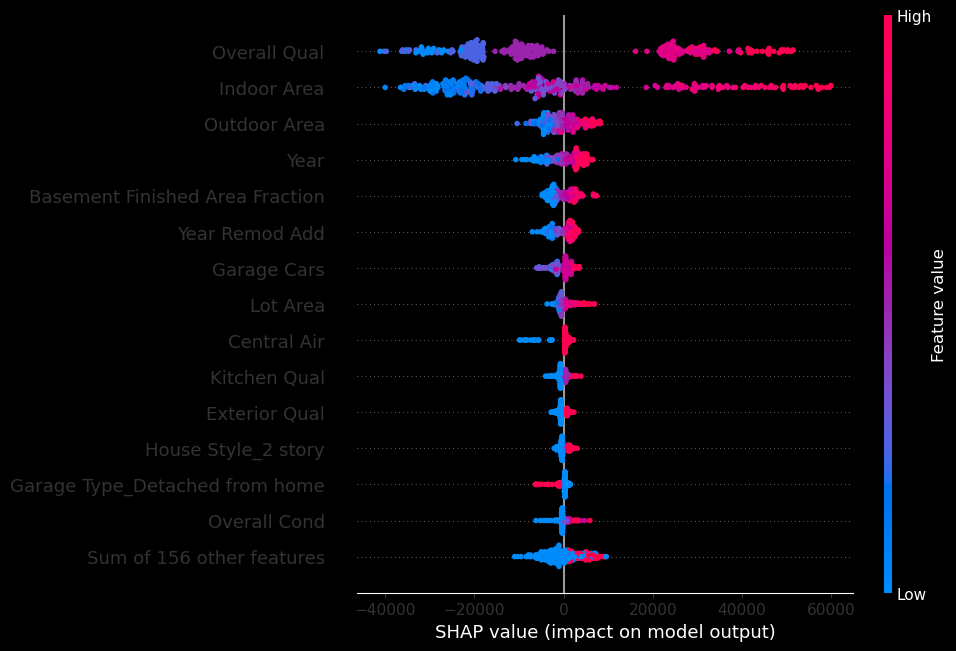

In [8]:
shap.plots.beeswarm(sv_exp, max_display=15)

#### 1.3.2 Bar - mean |SHAP| importance

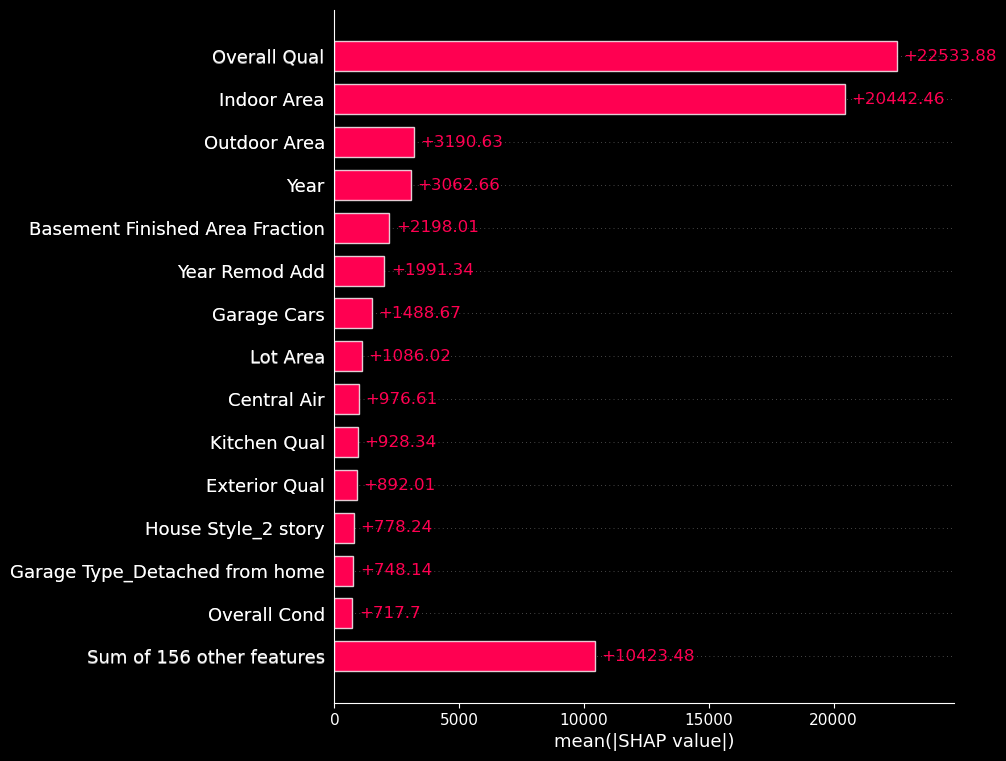

In [9]:
shap.plots.bar(sv_exp, max_display=15)

#### 1.3.3 Waterfalls - a cheap house and an expensive house

The same model, explained at both ends of its range: which features drag a prediction far
below the base value, and which stack it far above?

cheapest predicted:  $68,164


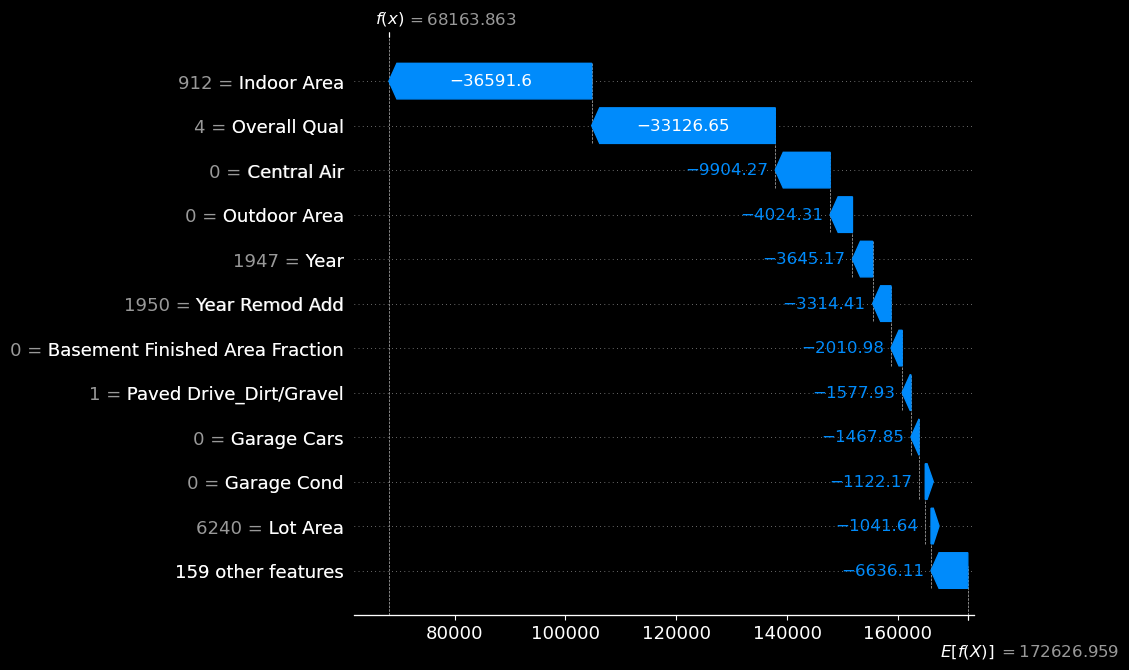

most expensive predicted: $304,639


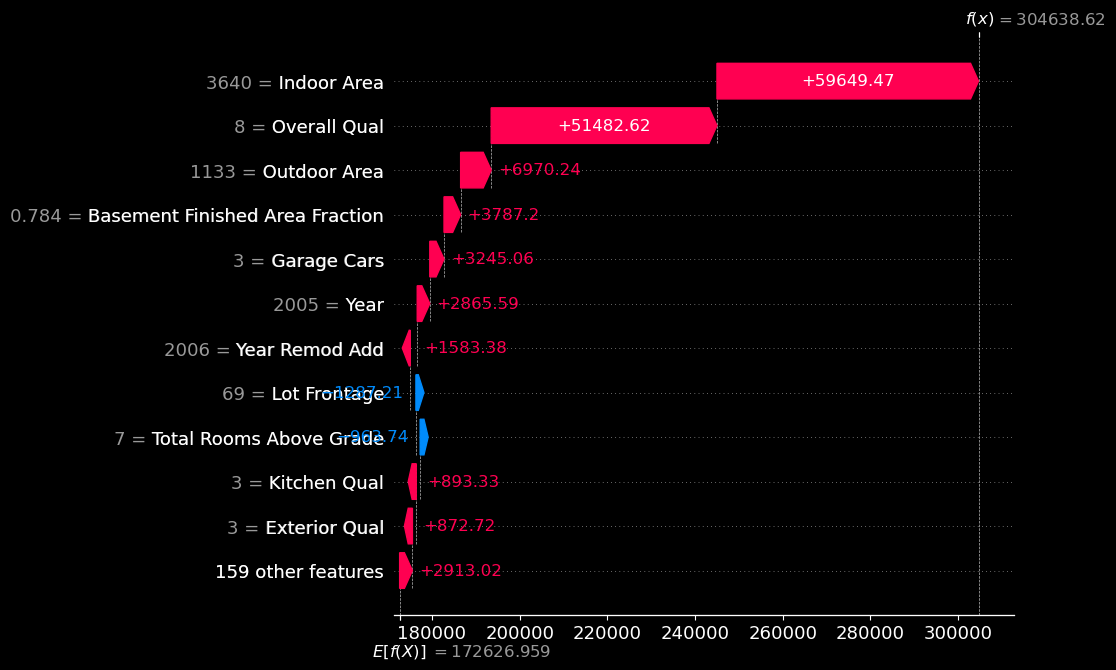

In [10]:
pred_expl = model.predict(X_expl)
idx_cheap = int(np.argmin(pred_expl))
idx_exp   = int(np.argmax(pred_expl))

print(f"cheapest predicted:  ${pred_expl[idx_cheap]:,.0f}")
shap.plots.waterfall(sv_exp[idx_cheap], max_display=12)

print(f"most expensive predicted: ${pred_expl[idx_exp]:,.0f}")
shap.plots.waterfall(sv_exp[idx_exp], max_display=12)

## 2. Fairness - does the model mis-price some neighborhoods?

`MetricFrame` computes any metric **per group**. For regression the interesting metrics are
error size (MAE, and MAPE as a fraction - 0.10 = off by 10%), fit quality ($R^2$), and the **mean residual** - whether the model
systematically over-predicts (positive) or under-predicts (negative) prices in a neighborhood.
A model can have great overall MAE while being reliably wrong in one part of town.

In [11]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import mean_absolute_percentage_error

def mean_residual(y_true, y_pred):
    return (y_pred - y_true).mean()   # positive = over-pricing

mf = MetricFrame(
    metrics={
        'MAE': mean_absolute_error,
        'MAPE': mean_absolute_percentage_error,
        'R^2': r2_score,
        'mean residual': mean_residual,
        'count': lambda yt, yp: len(yt),
    },
    y_true=y_test, y_pred=y_pred,
    sensitive_features=nbhd_test,
)

# Round per column - rounding the whole table to 0 decimals would crush
# MAPE and R^2 (both fractions) into misleading 0s and 1s.
mf.by_group.sort_values('MAPE').round(
    {'MAE': 0, 'MAPE': 3, 'R^2': 3, 'mean residual': 0, 'count': 0}
)

,MAE,MAPE,R^2,mean residual,count
Nbhd,,,,,
Gilbert,3988.0,0.021,0.951,-294.0,13.0
Sawyer West,10372.0,0.055,0.938,1713.0,17.0
College Creek,11726.0,0.059,0.887,2920.0,32.0
Stone Brook,15728.0,0.065,0.699,-232.0,5.0
Northridge,19950.0,0.071,0.536,-1380.0,7.0
Timberland,17738.0,0.072,0.610,-9052.0,11.0
Clear Creek,12390.0,0.072,0.292,-3049.0,6.0
Mitchell,11302.0,0.074,0.902,-1076.0,9.0
North Ames,10253.0,0.075,0.795,1589.0,45.0


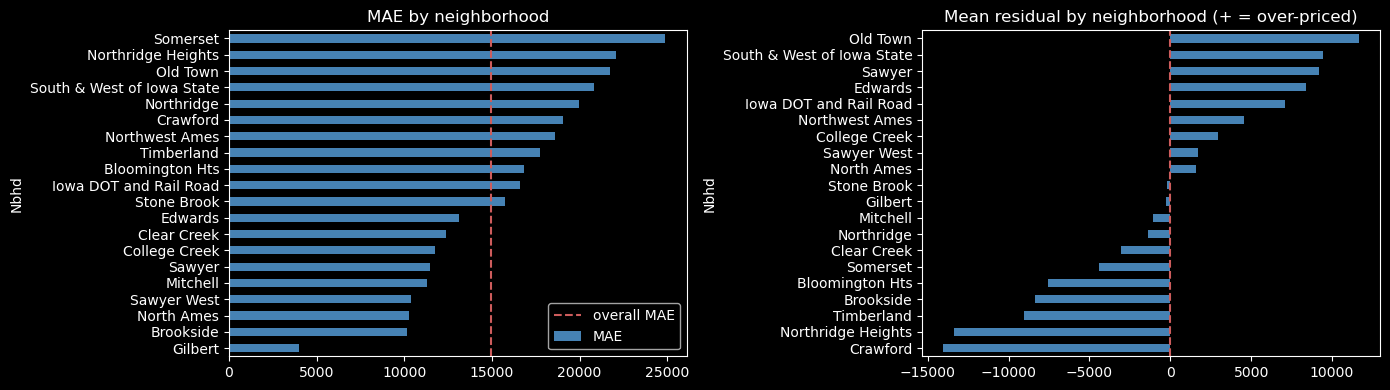

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mf.by_group['MAE'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(mean_absolute_error(y_test, y_pred), color='indianred',
                linestyle='--', label='overall MAE')
axes[0].set_title('MAE by neighborhood')
axes[0].legend()

mf.by_group['mean residual'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].axvline(0, color='indianred', linestyle='--')
axes[1].set_title('Mean residual by neighborhood (+ = over-priced)')

plt.tight_layout()
plt.show()

In [13]:
print(f"MAE difference (worst - best group): ${mf.difference()['MAE']:,.0f}")
print(f"MAE ratio      (best / worst group): {mf.ratio()['MAE']:.2f}")

MAE difference (worst - best group): $20,896
MAE ratio      (best / worst group): 0.16


### 2.1 Mitigation - constrained regression on **relative** error (`ExponentiatedGradient`)

The reductions approach is an **in-processing** mitigation: instead of editing the data (as a
pre-processor would) it *retrains* the model under an explicit fairness constraint. For regression
that constraint is `BoundedGroupLoss` - a ceiling on how badly the model may fit any single
neighborhood. The solver needs a base estimator that accepts `sample_weight`, so we use a linear
model and also fit a plain linear baseline for an apples-to-apples comparison.

**We constrain MAPE, not dollar MAE.** A neighborhood of \$500k homes will show a larger *dollar*
error than one of \$100k homes even when the model is equally good at both - the price level, and
its variance, are simply higher. Bounding dollar error would chase those expensive neighborhoods
for a gap that is not really unfairness. So we fit in **log-price** space: the absolute error there,
$\lvert\log y-\log\hat{y}\rvert$, approximates the *percentage* error $\lvert y-\hat{y}\rvert/y$
(per-sample MAPE), and predictions are mapped back to dollars with $\exp(\cdot)$.

#### 2.1.1 The loss function it optimizes

Write $A$ for the neighborhood and let the model $h$ predict $\log y$. Because
$\lvert \log y - \log\hat y\rvert \approx \lvert y-\hat y\rvert / y$, each neighborhood's mean loss
*is* (approximately) its MAPE. We want the smallest overall relative error subject to no
neighborhood's relative error exceeding a cap $\zeta$:

$$\min_{h}\; \mathbb{E}\!\left[\lvert \log y - h(X)\rvert\right]
\qquad\text{s.t.}\qquad
\mathbb{E}\!\left[\lvert \log y - h(X)\rvert \,\middle|\, A=a\right] \;\le\; \zeta
\quad\text{for every neighborhood } a.$$

The objective is the overall mean of that absolute log-loss; each constraint is a `BoundedGroupLoss`
built on `AbsoluteLoss` with the per-group cap $\zeta$ passed as `upper_bound`.
`ExponentiatedGradient` does not minimize this directly - it forms the **Lagrangian**

$$\mathcal{L}(h,\lambda) \;=\;
\underbrace{\mathbb{E}\!\left[\lvert \log y - h(X)\rvert\right]}_{\text{overall relative error}}
\;+\; \sum_{a}\lambda_a
\underbrace{\left(\mathbb{E}\!\left[\lvert \log y - h(X)\rvert \,\middle|\, A=a\right]-\zeta\right)}_{\text{how far group }a\text{'s MAPE exceeds the cap}},
\qquad \lambda_a\ge 0,\;\; \lVert\lambda\rVert_1\le B,$$

and solves the saddle point $\min_{h}\max_{\lambda}\mathcal{L}(h,\lambda)$ as a two-player game.
The $\lambda$-player raises the penalty $\lambda_a$ on whichever neighborhoods are over the cap (a
multiplicative-weights update, $\lambda \propto B\,e^{\theta}$); the $h$-player best-responds by
refitting a **sample-weighted** least squares that up-weights those neighborhoods. The multipliers
$\lambda_a$ *are* the regularization this method applies - the price it charges for group
unfairness.

#### 2.1.2 Controlling the regularization

Two knobs move the accuracy $\leftrightarrow$ fairness trade-off:

- **`upper_bound` = $\zeta$ - the main dial.** Now a cap on each neighborhood's **MAPE** (its mean
  $\lvert\log y-\log\hat y\rvert$), so `upper_bound=0.07` reads as *"no neighborhood above ~7% mean
  relative error."* It only *binds* when it sits **below** the worst neighborhood's unconstrained
  MAPE: set it too high and the solver hands back the unconstrained model; lower it and the group
  MAPEs are squeezed together at the cost of overall error.
- **`eps` - how hard that cap is enforced.** Fairlearn bounds the total penalty by
  $\lVert\lambda\rVert_1 \le B = 1/\texttt{eps}$, so **smaller `eps` $\Rightarrow$ larger $B$
  $\Rightarrow$ stronger enforcement** (constraint violation at most $\approx 2\,\texttt{eps}$), and
  since the step size is $\eta = \texttt{eta0}/B$, `eps` also sets how fast the $\lambda$'s move.

`max_iter` (default 50) and `eta0` (default 2.0) govern only the *convergence* of the game, not the
target it converges to.

In [14]:
from fairlearn.reductions import ExponentiatedGradient, BoundedGroupLoss, AbsoluteLoss
from sklearn.linear_model import LinearRegression

# Work in LOG price. Absolute error in log space, |log(y) - log(y_hat)|, is a *relative* error:
# it approximates the percentage error |y - y_hat| / y, i.e. per-sample MAPE. Bounding it per
# neighborhood therefore targets MAPE, not dollar MAE. That matters here - pricier neighborhoods
# carry larger dollar errors simply because their prices (and price variance) are larger, which a
# dollar-MAE bound would wrongly chase as "unfairness." A percentage bound asks each neighborhood
# to be predicted equally well in *relative* terms instead.
y_train_log = np.log(y_train.values)
log_min, log_max = y_train_log.min(), y_train_log.max()

# Plain linear baseline in log space (same base estimator, no constraint)
lin = LinearRegression().fit(X_train, y_train_log)
y_pred_lin = np.exp(lin.predict(X_test))

# AbsoluteLoss on log price ~ each neighborhood's MAPE. upper_bound is now a cap on that per-group
# MAPE (0.07 ~ "no neighborhood may sit above ~7% mean relative error"). It must be below the worst
# group's unconstrained relative error to actually bind (see the markdown above).
constraint = BoundedGroupLoss(AbsoluteLoss(log_min, log_max), upper_bound=0.07)

# eps sets the penalty budget B = 1/eps: smaller eps -> larger B -> the constraint is enforced
# harder. max_iter is how long the two-player game runs. Tune eps/upper_bound to move along the
# accuracy/fairness curve.
eg = ExponentiatedGradient(LinearRegression(), constraints=constraint,
                           eps=0.01, max_iter=50)
eg.fit(X_train, y_train_log, sensitive_features=nbhd_train)
y_pred_eg = np.exp(eg.predict(X_test))

for name, yp in [('Linear baseline', y_pred_lin), ('EG + BoundedGroupLoss', y_pred_eg)]:
    m = MetricFrame(metrics={'MAPE': mean_absolute_percentage_error},
                    y_true=y_test, y_pred=yp, sensitive_features=nbhd_test)
    print(f"{name:24s} overall MAPE {mean_absolute_percentage_error(y_test, yp):.3f}   "
          f"group MAPE gap {m.difference()['MAPE']:.3f}")

# Full per-neighborhood audit of the constrained model, same metrics as the baseline;
# sorted by MAPE now, since relative error is the criterion we constrained.
mf_eg = MetricFrame(
    metrics={
        'MAE': mean_absolute_error,
        'MAPE': mean_absolute_percentage_error,
        'R^2': r2_score,
        'mean residual': mean_residual,
        'count': lambda yt, yp: len(yt),
    },
    y_true=y_test, y_pred=y_pred_eg,
    sensitive_features=nbhd_test,
)

mf_eg.by_group.sort_values('MAPE', ascending=False).round(
    {'MAE': 0, 'MAPE': 3, 'R^2': 3, 'mean residual': 0, 'count': 0}
)

Linear baseline          overall MAPE 0.088   group MAPE gap 0.172
EG + BoundedGroupLoss    overall MAPE 0.109   group MAPE gap 0.124


,MAE,MAPE,R^2,mean residual,count
Nbhd,,,,,
Iowa DOT and Rail Road,15155.0,0.169,0.614,-11623.0,5.0
Northwest Ames,21055.0,0.156,0.054,-5866.0,13.0
Sawyer,16263.0,0.155,-0.495,8530.0,16.0
Crawford,25149.0,0.140,0.506,9532.0,16.0
Old Town,15592.0,0.136,0.829,1847.0,25.0
Edwards,14839.0,0.132,0.525,3619.0,26.0
Stone Brook,34607.0,0.126,0.009,2208.0,5.0
Somerset,23271.0,0.122,0.122,7200.0,23.0
Bloomington Hts,23513.0,0.116,0.196,-197.0,4.0


### 2.2 Before / after summary

Read this table the way an auditor would: overall error (cost) against the worst-vs-best neighborhood gap (equity). Because the mitigation now constrains **relative** error, the **`group MAPE gap`** column is the one it targets - watch it shrink for the constrained fit even as overall error rises. The dollar columns (`MAE`) sit alongside so you can see that the two lenses disagree: a neighborhood can look badly mispriced in dollars simply because its homes are expensive, yet be fine in percentage terms.

In [15]:
rows = {}
for name, yp in [('RF baseline', y_pred),
                 ('Linear baseline', y_pred_lin),
                 ('Linear + EG BoundedGroupLoss', y_pred_eg)]:
    m = MetricFrame(
        metrics={'MAE': mean_absolute_error, 'MAPE': mean_absolute_percentage_error},
        y_true=y_test, y_pred=yp, sensitive_features=nbhd_test)
    rows[name] = {
        'overall MAE': mean_absolute_error(y_test, yp),
        'group MAE gap': m.difference()['MAE'],
        'overall MAPE': mean_absolute_percentage_error(y_test, yp),
        'group MAPE gap': m.difference()['MAPE'],   # <- the metric the EG fit constrained
    }

pd.DataFrame(rows).T.round(
    {'overall MAE': 0, 'group MAE gap': 0, 'overall MAPE': 3, 'group MAPE gap': 3}
)

,overall MAE,group MAE gap,overall MAPE,group MAPE gap
RF baseline,14919.0,20896.0,0.099,0.317
Linear baseline,13713.0,16344.0,0.088,0.172
Linear + EG BoundedGroupLoss,17776.0,27596.0,0.109,0.124


### 2.3 Takeaways

- **SHAP for regression reads in dollars** - each feature's push above or below the average predicted price. Size and quality features dominate, exactly as the EDA suggested.
- **Group auditing found the story overall metrics hide**: error size and direction differ sharply by neighborhood, including systematic over/under-pricing.
- **The choice of error *metric* is itself a fairness decision.** We bound **MAPE**, not dollar MAE, so the model is not charged for the larger dollar errors that expensive neighborhoods carry just because their price level (and its variance) is higher - fitting in log-price space turns the constraint into a *relative* one.
- **Mitigation is an experiment, not a guarantee.** A loss-bound reduction only changes anything if the bound actually *binds* - set `upper_bound` above the worst group's unconstrained MAPE and you get the unmodified model back - and even when it binds it buys a smaller group gap by paying in overall accuracy. Sometimes the biggest equity lever is simply the *model family*. The audit table is the arbiter - where to sit on the cost/equity curve is a policy decision.
- The classification versions of both tools - with demographic sensitive features and threshold-based mitigation - are in `U1_Diabetes-7_Interp`.

## Review

- **SHAP explains a single prediction** by distributing the gap between the model's average output
  and this output across the features, in the unique way satisfying the Shapley axioms.
- **For regression the SHAP values are in the units of the target** — dollars here — which makes
  them directly readable: this feature added \$12,000 to the estimate.
- **Global and local views come from the same numbers.** The bar and beeswarm plots aggregate the
  per-prediction values that waterfall and force plots show one at a time.
- **Fairness for a regressor is about error disparity**, not selection rate: the question is whether
  the model is systematically less accurate for some groups, which `MetricFrame` answers by
  computing the error metric per group.
- **A model can be accurate overall and unfair in the aggregate**, which is why the disaggregated
  view is not optional.